In [13]:
import zipfile
import pandas as pd

import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['default', 'science', 'no-latex'])

from code_utils.utils_basic import PROJECT_PATH

In [14]:
def load_csv_from_zip(zip_path, csv_path, **kwargs):
    """
    Load a CSV file from a ZIP archive into a pandas DataFrame.
    """
    with zipfile.ZipFile(zip_path, 'r') as zf:
        with zf.open(csv_path) as f:
            df = pd.read_csv(f, **kwargs)
    return df
# ============================================================
def load_landuse_composition(buffer):
    # Load land use composition within specified buffer
    zip_path = PROJECT_PATH / 'data/features.zip'

    landuse = load_csv_from_zip(
        zip_path,
        csv_path = f'busstop_landuse_buffer_{buffer}.csv',
        dtype = {'Id' : str},
        index_col = 0,
    )
    landuse.index = landuse.index.astype(str).str.zfill(5)

    return landuse
# =============================================================
def compute_landuse_aggregate_composition(landuse, cluster_label_col):
    # Aggregate land use composition by cluster
    landuse_agg = (landuse.copy()
        .groupby(cluster_label_col).sum()
        .rename(index = lambda x : f'Cluster {int(x)+1}')
    )
    # Convert to percentage
    landuse_agg = landuse_agg.div(
        landuse_agg.sum(axis=1), axis=0) * 100.

    return landuse_agg
# =============================================================


landuse_name = {
    'RES' : 'Residential',
    'BUS' : 'Business',
    'COM' : 'Commercial',
    'REC' : 'Recreational',
    'EDU' : 'Educational',
    'OPS' : 'Open space',
    'TRS' : 'Transportation',
    'DEL' : 'Others',
}

In [15]:
# Load cluster labels
cluster_label = load_csv_from_zip(
    zip_path = PROJECT_PATH / 'results/results.zip',
    csv_path = 'clustering/clustering_results_kmeans.csv',
    index_col = 0, header = 0,
    dtype = {'pt_code': str}
)
cluster_label.index = cluster_label.index.astype(str).str.zfill(5)

# Load land use composition data
landuse = load_landuse_composition(buffer=200)
landuse = landuse.join(cluster_label['label'].copy(), how='inner')
landuse_200 = compute_landuse_aggregate_composition(landuse, 'label')
landuse_200 = landuse_200.rename(columns = landuse_name)[landuse_name.values()]


landuse = load_landuse_composition(buffer=400)
landuse = landuse.join(cluster_label['label'].copy(), how='inner')
landuse_400 = compute_landuse_aggregate_composition(landuse, 'label')
landuse_400 = landuse_400.rename(columns = landuse_name)[landuse_name.values()]

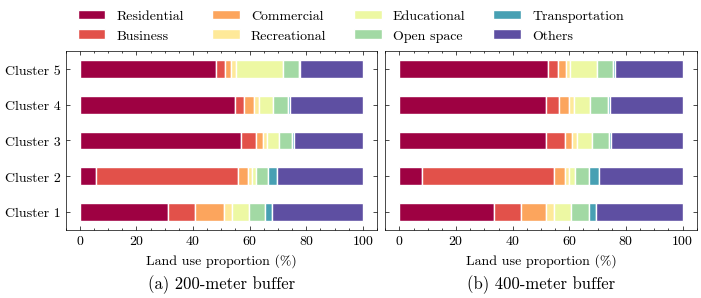

In [16]:
fig, axes = plt.subplots(nrows = 1, ncols = 2,
    figsize = (7, 2.5), constrained_layout = True, sharex=True, sharey=True)
axes = axes.flatten()

ax = axes[0]
ax = landuse_200.plot.barh(
    stacked = True,
    cmap = 'Spectral',
    edgecolor = 'white',
    legend = False,
    ax = ax,
)
ax.set_ylabel(None)
ax.set_xlabel('Land use proportion (%)')
ax.set_xlim([-5, 105])
ax.tick_params(axis='y', which='minor', left=False, right=False)
ax.text(
    0.5, -0.25, '(a) 200-meter buffer',
    fontsize = 12,
    va = 'top', ha = 'center',
    transform = ax.transAxes,
)


ax = axes[1]
ax = landuse_400.plot.barh(
    stacked = True,
    cmap = 'Spectral',
    edgecolor = 'white',
    legend = False,
    ax = ax,
)
ax.set_ylabel(None)
ax.set_xlabel('Land use proportion (%)')
ax.set_xlim([-5, 105])
ax.tick_params(axis='y', which='minor', left=False, right=False)

ax.text(
    0.5, -0.25, '(b) 400-meter buffer',
    fontsize = 12,
    va = 'top', ha = 'center',
    transform = ax.transAxes,
)

# Add legend
handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc = 'upper center',
    ncol = 4, frameon = False,
    fontsize = 10,
    bbox_to_anchor = (0.5, 1.2),
)


# Save figure
# fig.savefig('landuse_composition_by_cluster.pdf',
#     dpi = 600, bbox_inches = 'tight', format = 'pdf',)
# fig.savefig('landuse_composition_by_cluster.jpg',
#     dpi = 600, bbox_inches = 'tight')